In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv("covid_asia__2020_2023.csv")

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16784\1710303344.py:8: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("covid_asia__2020_2023.csv")


In [2]:
df.describe()

,new_confirmed,new_deceased,new_recovered,cumulative_confirmed,cumulative_deceased,cumulative_recovered,new_tested,cumulative_tested,new_persons_vaccinated,cumulative_persons_vaccinated,...,contact_tracing,facial_coverings,population,population_density,gdp_per_capita_usd,human_development_index,hospital_beds_per_1000,life_expectancy,average_temperature_celsius,relative_humidity
count,1.394762e+06,1.335235e+06,1.177088e+06,1.395920e+06,1.337191e+06,1.178167e+06,6.206840e+05,6.300020e+05,2.795710e+05,2.786850e+05,...,81243.000000,84287.000000,2.790656e+06,47568.000000,44595.000000,48559.000000,9910.000000,47568.000000,2.977364e+06,2.977361e+06
mean,2.325621e+02,2.150905e+00,9.903541e+01,7.880970e+04,9.934037e+02,4.182353e+04,4.250145e+03,1.572167e+06,1.331241e+04,2.821446e+06,...,1.566264,2.572247,3.508188e+06,457.603354,13081.155556,2.159224,2.740000,74.218304,2.356101e+01,6.613559e+01
std,4.652485e+03,2.313785e+02,2.953515e+04,8.691119e+05,1.090763e+04,2.708767e+05,6.671115e+05,2.149199e+07,9.002894e+05,3.781963e+07,...,0.670555,1.114102,3.949438e+07,1232.405530,16501.822926,9.924119,3.105056,4.739723,6.658831e+00,1.617443e+01
min,-1.476039e+06,-6.381100e+04,-6.602802e+06,0.000000e+00,0.000000e+00,-3.000000e+00,-3.541552e+08,0.000000e+00,-1.510100e+04,0.000000e+00,...,0.000000,0.000000,5.300000e+01,2.110000,502.000000,0.452000,0.500000,64.486000,-3.253704e+01,5.268462e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,1.570000e+02,1.000000e+00,8.800000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,1.000000,2.000000,9.690000e+02,66.015500,2534.000000,0.640000,0.800000,71.041000,1.976984e+01,5.466470e+01
50%,2.000000e+00,0.000000e+00,1.000000e+00,2.107000e+03,1.700000e+01,1.488000e+03,0.000000e+00,6.582000e+03,0.000000e+00,3.919000e+03,...,2.000000,3.000000,1.630555e+05,116.616000,4793.000000,0.741000,1.650000,74.150000,2.612346e+01,6.825629e+01
75%,2.200000e+01,0.000000e+00,1.400000e+01,1.519500e+04,1.690000e+02,1.201700e+04,0.000000e+00,1.439820e+05,1.200000e+01,1.962000e+04,...,2.000000,3.000000,1.306081e+06,342.832250,15474.000000,0.821000,2.700000,76.989000,2.798611e+01,7.990243e+01
max,1.479128e+06,6.383000e+04,6.604812e+06,4.451648e+07,5.282500e+05,7.959133e+06,3.541856e+08,9.214000e+09,4.505000e+08,1.302773e+09,...,2.000000,4.000000,1.439324e+09,8357.633000,65233.000000,70.910000,11.500000,84.210976,4.306944e+01,1.000000e+02


In [3]:
df

,country_name,subregion1_name,subregion2_name,date,new_confirmed,new_deceased,new_recovered,cumulative_confirmed,cumulative_deceased,cumulative_recovered,...,contact_tracing,facial_coverings,population,population_density,gdp_per_capita_usd,human_development_index,hospital_beds_per_1000,life_expectancy,average_temperature_celsius,relative_humidity
0,Afghanistan,Nimruz,NaN,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,149000.0,NaN,NaN,NaN,NaN,NaN,11.433333,41.708205
1,Afghanistan,Farah,NaN,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,563026.0,NaN,NaN,NaN,NaN,NaN,6.375000,63.012490
2,Afghanistan,Daykundi,NaN,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,516504.0,NaN,NaN,NaN,NaN,NaN,3.203704,67.876118
3,Afghanistan,Sar-e Pol,NaN,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,532000.0,NaN,NaN,NaN,NaN,NaN,3.685185,77.899240
4,Afghanistan,Kabul,NaN,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,4012000.0,NaN,NaN,NaN,NaN,NaN,5.166667,72.300365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3274259,Yemen,NaN,NaN,2022-09-13,0.0,0.0,NaN,11932.0,2155.0,NaN,...,NaN,NaN,29825968.0,56.492,968.0,0.452,NaN,66.096,35.111111,17.975208
3274260,Yemen,NaN,NaN,2022-09-14,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,29825968.0,56.492,968.0,0.452,NaN,66.096,NaN,NaN
3274261,Yemen,NaN,NaN,2022-09-15,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,29825968.0,56.492,968.0,0.452,NaN,66.096,NaN,NaN
3274262,Yemen,NaN,NaN,2022-09-16,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,29825968.0,56.492,968.0,0.452,NaN,66.096,NaN,NaN


In [4]:
df.isna().sum()

country_name                                   0
subregion1_name                            47568
subregion2_name                           416220
date                                           0
new_confirmed                            1879502
new_deceased                             1939029
new_recovered                            2097176
cumulative_confirmed                     1878344
cumulative_deceased                      1937073
cumulative_recovered                     2096097
new_tested                               2653580
cumulative_tested                        2644262
new_persons_vaccinated                   2994693
cumulative_persons_vaccinated            2995579
new_persons_fully_vaccinated             2995511
cumulative_persons_fully_vaccinated      2996389
new_vaccine_doses_administered           2994411
cumulative_vaccine_doses_administered    2994370
stringency_index                         3189811
school_closing                           3189036
workplace_closing   

In [5]:
df.shape

(3274264, 34)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3274264 entries, 0 to 3274263
Data columns (total 34 columns):
 #   Column                                 Dtype  
---  ------                                 -----  
 0   country_name                           object 
 1   subregion1_name                        object 
 2   subregion2_name                        object 
 3   date                                   object 
 4   new_confirmed                          float64
 5   new_deceased                           float64
 6   new_recovered                          float64
 7   cumulative_confirmed                   float64
 8   cumulative_deceased                    float64
 9   cumulative_recovered                   float64
 10  new_tested                             float64
 11  cumulative_tested                      float64
 12  new_persons_vaccinated                 float64
 13  cumulative_persons_vaccinated          float64
 14  new_persons_fully_vaccinated           float64
 15

In [7]:
df = df.sort_values(['country_name', 'date'])

In [8]:
# 1) Ca nhiễm / tử vong → điền 0
df[['new_confirmed', 'new_deceased']] = df[['new_confirmed', 'new_deceased']].fillna(0)

# 2) Tính số liệu tích lũy
df['cumulative_confirmed'] = df.groupby('country_name')['new_confirmed'].cumsum()
df['cumulative_deceased'] = df.groupby('country_name')['new_deceased'].cumsum()

# 3) Vaccine → nội suy + tích lũy
df['new_vaccine_doses_administered'] = (
    df.groupby('country_name')['new_vaccine_doses_administered']
      .apply(lambda x: x.interpolate().fillna(0))
)

df['new_vaccine_doses_administered'] = df['new_vaccine_doses_administered'].clip(lower=0)

df['cumulative_vaccine_doses_administered'] = (
    df.groupby('country_name')['new_vaccine_doses_administered'].cumsum()
)

# 4) Chính sách → ffill + bfill → median nếu vẫn thiếu
policy_cols = [
    'stringency_index','school_closing','workplace_closing',
    'stay_at_home_requirements','restrictions_on_internal_movement'
]
df[policy_cols] = df.groupby('country_name')[policy_cols].apply(lambda x: x.ffill().bfill())
df[policy_cols] = df[policy_cols].fillna(df[policy_cols].median())

# 5) Kinh tế - xã hội → median theo quốc gia → median toàn dataset nếu cần
meta_cols = ['population','population_density','gdp_per_capita_usd','human_development_index']
df[meta_cols] = df.groupby('country_name')[meta_cols].transform(lambda x: x.fillna(x.median()))
df[meta_cols] = df[meta_cols].fillna(df[meta_cols].median())

# 6) Môi trường → median theo quốc gia → median toàn dataset nếu vẫn thiếu
env_cols = ['average_temperature_celsius','relative_humidity']
df[env_cols] = df.groupby('country_name')[env_cols].transform(lambda x: x.fillna(x.median()))
df[env_cols] = df[env_cols].fillna(df[env_cols].median())

print("✅ Hoàn tất bước điền missing và tích lũy")


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16784\3671679800.py:11: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .apply(lambda x: x.interpolate().fillna(0))
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16784\3671679800.py:25: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  df[policy_cols] = df.gro

✅ Hoàn tất bước điền missing và tích lũy


In [9]:
def remove_outliers(group, col):
    Q1 = group[col].quantile(0.25)
    Q3 = group[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return group[(group[col] >= lower) & (group[col] <= upper)]

# Các cột số cần loại outlier

cols_outlier = ['new_confirmed','new_deceased','stringency_index',
                'cumulative_vaccine_doses_administered']

for col in cols_outlier:
    before = df.shape[0]
    df = df.groupby('country_name', group_keys=False).apply(lambda g: remove_outliers(g, col))
    after = df.shape[0]
    print(f"{col}: loại {before - after} dòng")


new_confirmed: loại 460846 dòng
new_deceased: loại 55579 dòng
stringency_index: loại 40572 dòng
cumulative_vaccine_doses_administered: loại 900 dòng


In [10]:
# Danh sách cột nên giữ
keep_columns = [
    'country_name','date',
    'new_confirmed','new_deceased',
    'cumulative_confirmed','cumulative_deceased',
    'new_vaccine_doses_administered','cumulative_vaccine_doses_administered',
    'population','population_density',
    'stringency_index','school_closing','workplace_closing',
    'stay_at_home_requirements','restrictions_on_internal_movement',
    'gdp_per_capita_usd','human_development_index',
    'average_temperature_celsius','relative_humidity'
]

# Lọc dataframe chỉ giữ các cột cần thiết
df = df[keep_columns]
df

,country_name,date,new_confirmed,new_deceased,cumulative_confirmed,cumulative_deceased,new_vaccine_doses_administered,cumulative_vaccine_doses_administered,population,population_density,stringency_index,school_closing,workplace_closing,stay_at_home_requirements,restrictions_on_internal_movement,gdp_per_capita_usd,human_development_index,average_temperature_celsius,relative_humidity
0,Afghanistan,2020-01-01,0.0,0.0,0.0,0.0,0.0,0.0,149000.0,59.627,0.00,0.0,0.0,0.0,0.0,502.0,0.498,11.433333,41.708205
1,Afghanistan,2020-01-01,0.0,0.0,0.0,0.0,0.0,0.0,563026.0,59.627,0.00,0.0,0.0,0.0,0.0,502.0,0.498,6.375000,63.012490
2,Afghanistan,2020-01-01,0.0,0.0,0.0,0.0,0.0,0.0,516504.0,59.627,0.00,0.0,0.0,0.0,0.0,502.0,0.498,3.203704,67.876118
3,Afghanistan,2020-01-01,0.0,0.0,0.0,0.0,0.0,0.0,532000.0,59.627,0.00,0.0,0.0,0.0,0.0,502.0,0.498,3.685185,77.899240
4,Afghanistan,2020-01-01,0.0,0.0,0.0,0.0,0.0,0.0,4012000.0,59.627,0.00,0.0,0.0,0.0,0.0,502.0,0.498,5.166667,72.300365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3274259,Yemen,2022-09-13,0.0,0.0,11932.0,2155.0,17648.0,15726291.0,29825968.0,56.492,11.11,0.0,0.0,2.0,0.0,968.0,0.452,35.111111,17.975208
3274260,Yemen,2022-09-14,0.0,0.0,11932.0,2155.0,17648.0,15743939.0,29825968.0,56.492,11.11,0.0,0.0,2.0,0.0,968.0,0.452,30.416666,19.234222
3274261,Yemen,2022-09-15,0.0,0.0,11932.0,2155.0,17648.0,15761587.0,29825968.0,56.492,11.11,0.0,0.0,2.0,0.0,968.0,0.452,30.416666,19.234222
3274262,Yemen,2022-09-16,0.0,0.0,11932.0,2155.0,17648.0,15779235.0,29825968.0,56.492,11.11,0.0,0.0,2.0,0.0,968.0,0.452,30.416666,19.234222


In [11]:
df_analysis = df.copy()

# One-hot quốc gia
df_analysis = pd.get_dummies(df_analysis, columns=['country_name'], drop_first=True)

# Xóa cột date (không dùng trong mô hình thống kê / ML)
df_analysis = df_analysis.drop(columns=['date'])

# Chuẩn hóa các cột số (KHÔNG chuẩn hóa các cột one-hot)
num_cols_analysis = [
    'new_confirmed','cumulative_confirmed','new_deceased','cumulative_deceased',
    'cumulative_vaccine_doses_administered','gdp_per_capita_usd','population_density',
    'average_temperature_celsius','relative_humidity','population'
]

scaler = MinMaxScaler()
df_analysis[num_cols_analysis] = scaler.fit_transform(df_analysis[num_cols_analysis])

print("✅ df_analysis đã làm sạch và chuẩn hóa hoàn tất")
df_analysis.head(20)

✅ df_analysis đã làm sạch và chuẩn hóa hoàn tất


,new_confirmed,new_deceased,cumulative_confirmed,cumulative_deceased,new_vaccine_doses_administered,cumulative_vaccine_doses_administered,population,population_density,stringency_index,school_closing,...,country_name_Syria,country_name_Taiwan,country_name_Tajikistan,country_name_Thailand,country_name_Turkey,country_name_Turkmenistan,country_name_United Arab Emirates,country_name_Uzbekistan,country_name_Vietnam,country_name_Yemen
0,0.000438,0.015,0.003601,0.0,0.0,0.0,0.000103,0.006884,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,0.000438,0.015,0.003601,0.0,0.0,0.0,0.000391,0.006884,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,0.000438,0.015,0.003601,0.0,0.0,0.0,0.000359,0.006884,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,0.000438,0.015,0.003601,0.0,0.0,0.0,0.000370,0.006884,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,0.000438,0.015,0.003601,0.0,0.0,0.0,0.002787,0.006884,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
5,0.000438,0.015,0.003601,0.0,0.0,0.0,0.000120,0.006884,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
6,0.000438,0.015,0.003601,0.0,0.0,0.0,0.003468,0.006884,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
7,0.000438,0.015,0.003601,0.0,0.0,0.0,0.000773,0.006884,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
8,0.000438,0.015,0.003601,0.0,0.0,0.0,0.000274,0.006884,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
9,0.000438,0.015,0.003601,0.0,0.0,0.0,0.000303,0.006884,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
df_analysis.isna().sum()

new_confirmed                        0
new_deceased                         0
cumulative_confirmed                 0
cumulative_deceased                  0
new_vaccine_doses_administered       0
                                    ..
country_name_Turkmenistan            0
country_name_United Arab Emirates    0
country_name_Uzbekistan              0
country_name_Vietnam                 0
country_name_Yemen                   0
Length: 64, dtype: int64

In [13]:
df_forecast = df[['country_name','date','new_confirmed',
                  'stringency_index',
                  'cumulative_vaccine_doses_administered',
                  'average_temperature_celsius','relative_humidity']].copy()

df_forecast['date'] = pd.to_datetime(df_forecast['date'])
df_forecast = df_forecast.sort_values(['country_name','date'])

print("✅ df_forecast đã sẵn sàng cho mô hình dự báo")
df_forecast.head()


✅ df_forecast đã sẵn sàng cho mô hình dự báo


,country_name,date,new_confirmed,stringency_index,cumulative_vaccine_doses_administered,average_temperature_celsius,relative_humidity
0,Afghanistan,2020-01-01,0.0,0.0,0.0,11.433333,41.708205
1,Afghanistan,2020-01-01,0.0,0.0,0.0,6.375000,63.012490
2,Afghanistan,2020-01-01,0.0,0.0,0.0,3.203704,67.876118
3,Afghanistan,2020-01-01,0.0,0.0,0.0,3.685185,77.899240
4,Afghanistan,2020-01-01,0.0,0.0,0.0,5.166667,72.300365


In [14]:
df_forecast.isna().sum()

country_name                             0
date                                     0
new_confirmed                            0
stringency_index                         0
cumulative_vaccine_doses_administered    0
average_temperature_celsius              0
relative_humidity                        0
dtype: int64

In [15]:
# Tên file CSV cho dữ liệu phân tích
file_analysis = 'df_analysis.csv'

# Xuất DataFrame df_analysis sang CSV
df_analysis.to_csv(file_analysis, index=False)

# Tên file CSV cho dữ liệu dự báo
file_forecast = 'df_forecast.csv'

# Xuất DataFrame df_forecast sang CSV
df_forecast.to_csv(file_forecast, index=False)

print(f"✅ Đã lưu df_analysis sang file: {file_analysis}")
print(f"✅ Đã lưu df_forecast sang file: {file_forecast}")

✅ Đã lưu df_analysis sang file: df_analysis.csv
✅ Đã lưu df_forecast sang file: df_forecast.csv


In [16]:
# Tên file CSV cho dữ liệu phân tích
file_analysis = 'df_analysis.csv'
# Xuất DataFrame df_analysis sang CSV
df_analysis.to_csv(file_analysis, index=False)
print(f"✅ Đã lưu df_analysis sang file: {file_analysis}")

✅ Đã lưu df_analysis sang file: df_analysis.csv


# TRỰC QUAN HÓA DỮ LIỆU 


## 1. DỮ LIỆU df_analysis
### Phân tích nhân quả/tương quan/thống kê: Tìm hiểu mối quan hệ giữa các yếu tố (chính sách, kinh tế, môi trường, vaccine, quốc gia) với số ca nhiễm/tử vong

### 1.1 MA TRẬN TƯƠNG QUAN -> Cho biết yếu tố nào liên quan mạnh với ca nhiễm

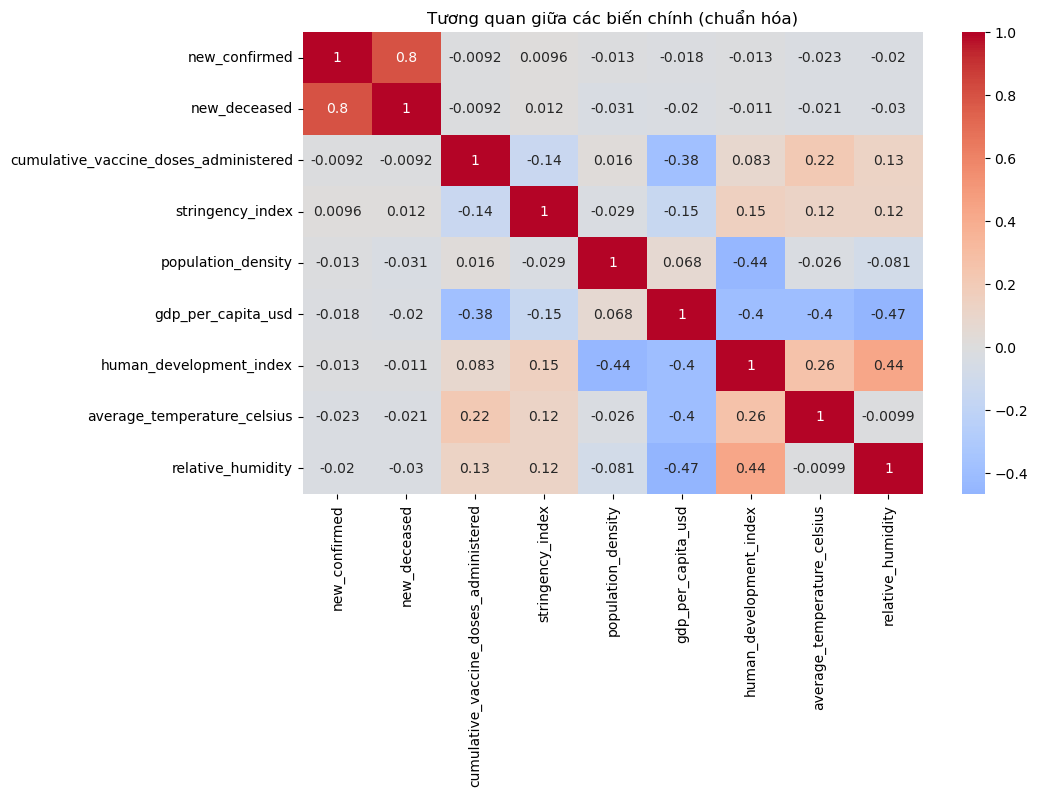

In [17]:

focus = ['new_confirmed','new_deceased','cumulative_vaccine_doses_administered',
         'stringency_index','population_density','gdp_per_capita_usd',
         'human_development_index','average_temperature_celsius','relative_humidity']
plt.figure(figsize=(10,6))
sns.heatmap(df_analysis[focus].corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Tương quan giữa các biến chính (chuẩn hóa)")
plt.show()


### 1.2 Biểu đồ boxplot Phân phối ca nhiễm theo từng quốc gia (Boxplot so sánh chính sách) -> Đánh giá hiệu quả chính sách phòng chống dịch.

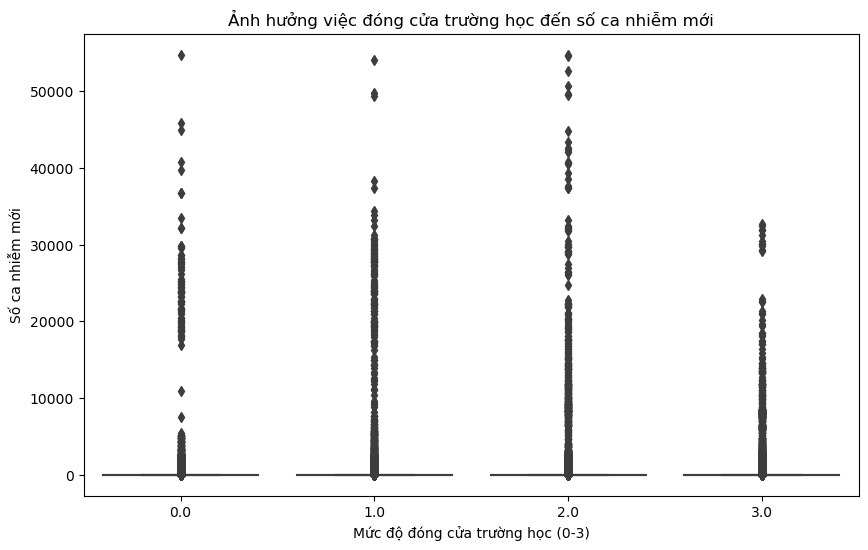

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='school_closing', y='new_confirmed')
plt.title("Ảnh hưởng việc đóng cửa trường học đến số ca nhiễm mới")
plt.xlabel("Mức độ đóng cửa trường học (0-3)")
plt.ylabel("Số ca nhiễm mới")
plt.show()

### 1.3. Ảnh hưởng Vaccine đến ca nhiễm (Scatter Trend) -> Cho thấy tiêm nhiều vaccine thì ca mới có giảm không.

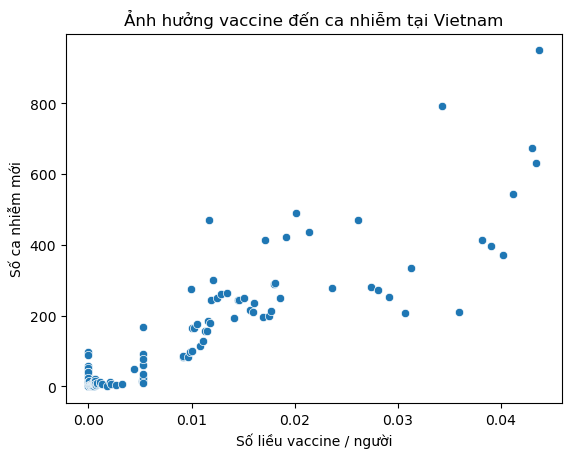

In [19]:
country = "Vietnam"
data = df[df["country_name"]==country]

data = df[df["country_name"]==country].copy()
data["vaccine_per_person"] = data["cumulative_vaccine_doses_administered"] / data["population"]

sns.scatterplot(data=data, x="vaccine_per_person", y="new_confirmed")
plt.title(f"Ảnh hưởng vaccine đến ca nhiễm tại {country}")
plt.xlabel("Số liều vaccine / người")
plt.ylabel("Số ca nhiễm mới")
plt.show()



## 2. DỮ LIỆU df_forecast
### Phân tích chuỗi thời gian/Dự báo: Xây dựng mô hình để dự đoán xu hướng số ca nhiễm mới trong tương lai

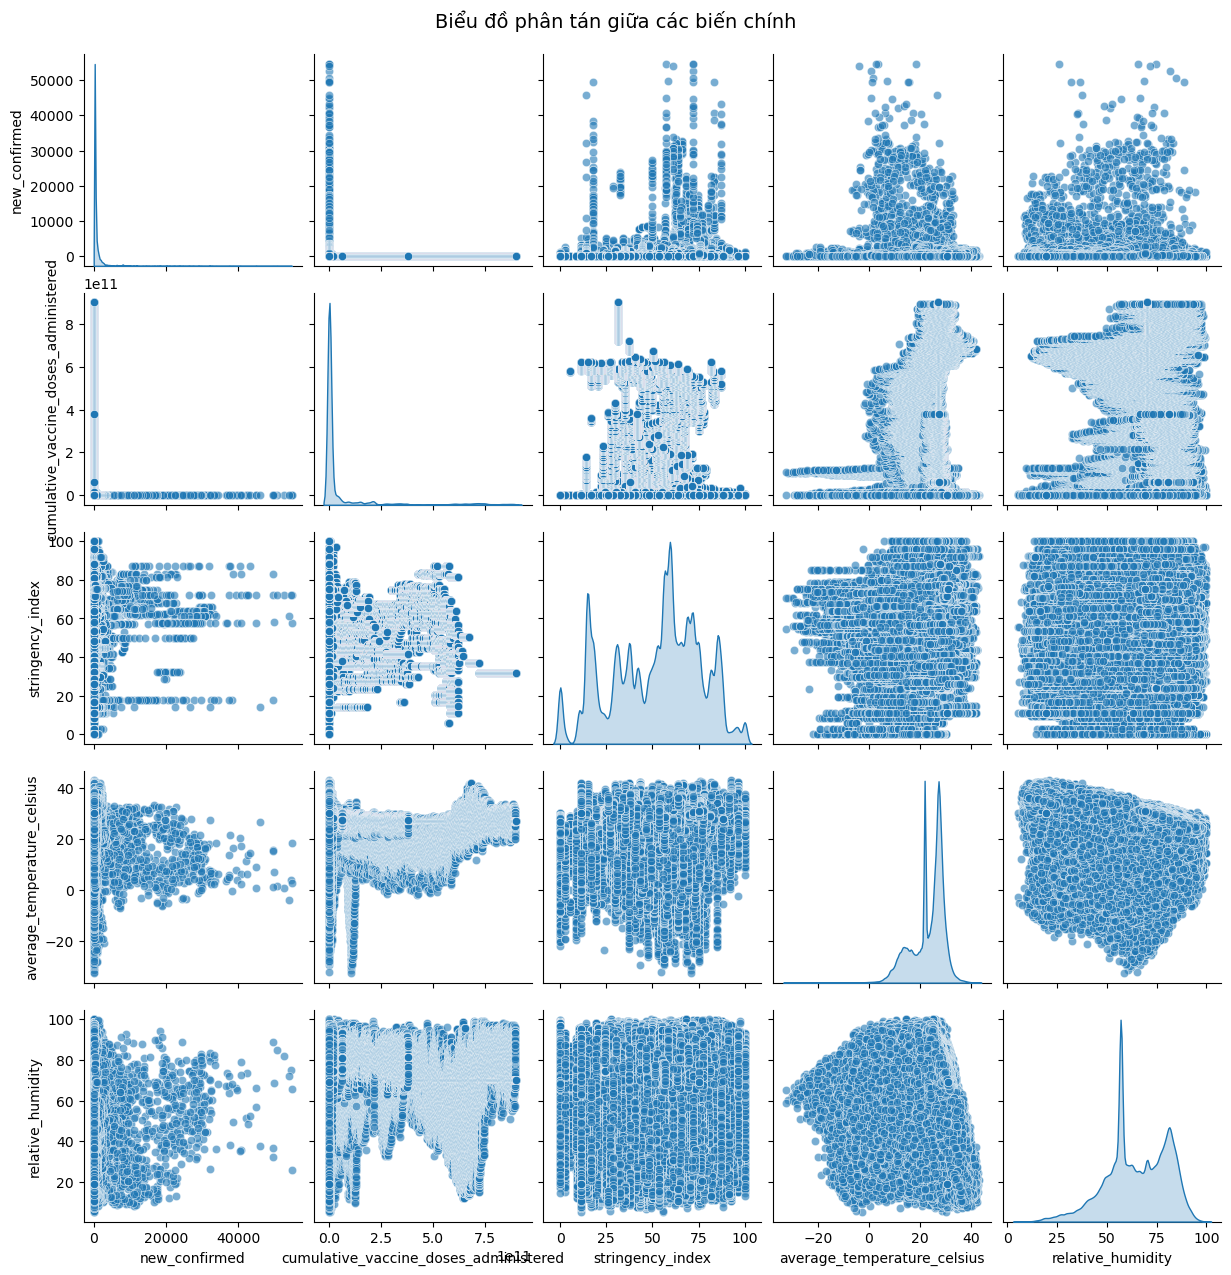

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

focus = [
    'new_confirmed', 
    'new_deceased', 
    'cumulative_vaccine_doses_administered',
    'stringency_index', 
    'population_density', 
    'gdp_per_capita_usd',
    'human_development_index', 
    'average_temperature_celsius', 
    'relative_humidity'
]

cols = [c for c in focus if c in df_forecast.columns]

sns.pairplot(df_forecast[cols], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle("Biểu đồ phân tán giữa các biến chính", y=1.02, fontsize=14)
plt.show()


## 2.1. Đường diễn biến ca nhiễm theo thời gian

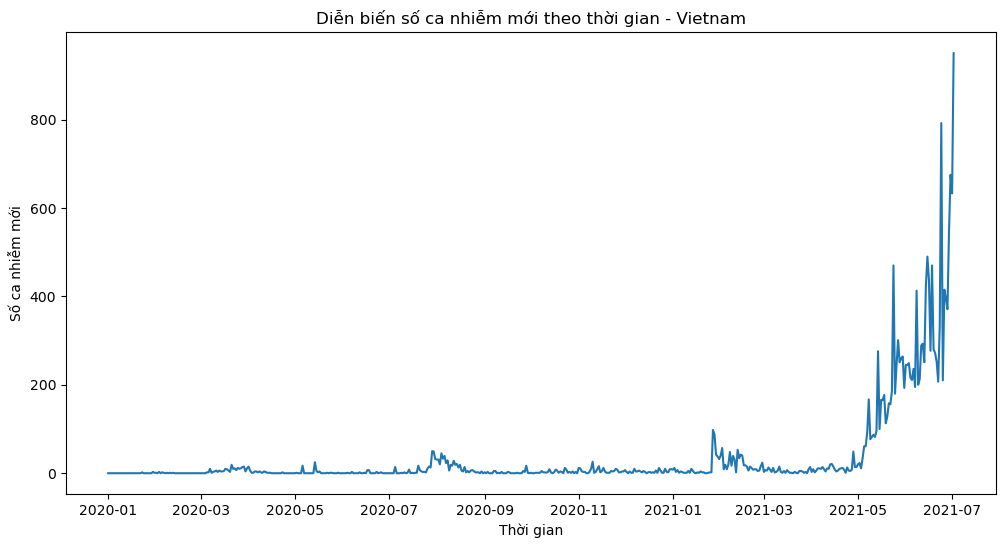

In [21]:
country = "Vietnam"
data = df_forecast[df_forecast["country_name"]==country]

plt.figure(figsize=(12,6))
plt.plot(data["date"], data["new_confirmed"])
plt.title(f"Diễn biến số ca nhiễm mới theo thời gian - {country}")
plt.xlabel("Thời gian")
plt.ylabel("Số ca nhiễm mới")
plt.show()


## 2.2. Đường trung bình trượt (Rolling Mean) để làm mượt dữ liệu
### Dùng để chuẩn bị đưa vào mô hình dự báo.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16784\1865397530.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["new_confirmed_7d"] = data["new_confirmed"].rolling(7).mean()


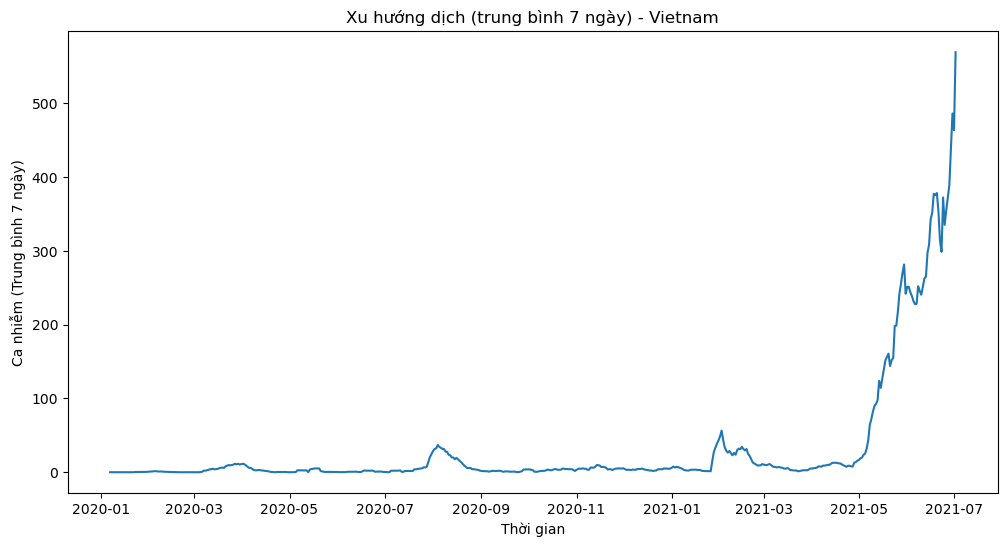

In [22]:
data["new_confirmed_7d"] = data["new_confirmed"].rolling(7).mean()

plt.figure(figsize=(12,6))
plt.plot(data["date"], data["new_confirmed_7d"])
plt.title(f"Xu hướng dịch (trung bình 7 ngày) - {country}")
plt.xlabel("Thời gian")
plt.ylabel("Ca nhiễm (Trung bình 7 ngày)")
plt.show()


### 2.3. Ảnh hưởng chính sách đến xu hướng ca nhiễm -> Cho thấy khi chính sách siết chặt → dịch có giảm hay không.

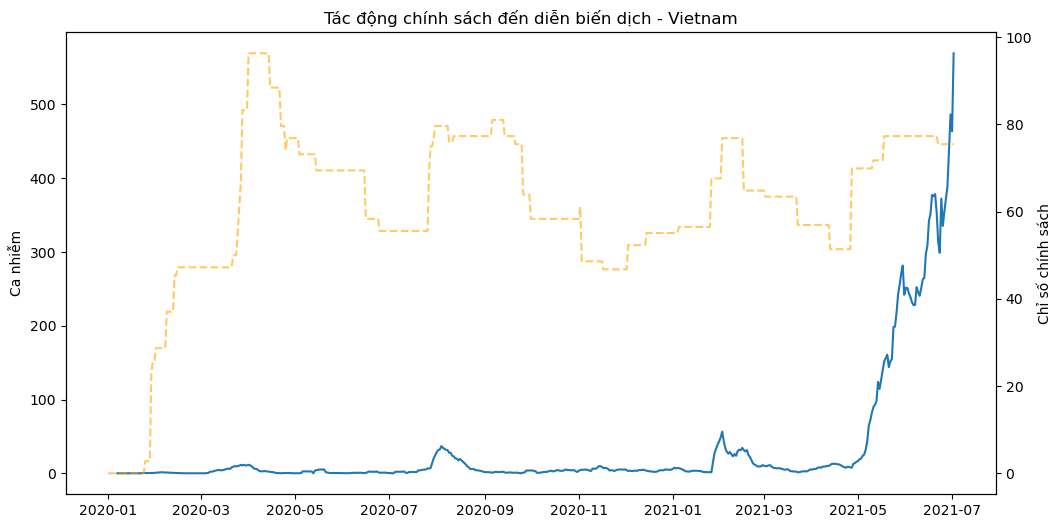

In [23]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(data["date"], data["new_confirmed_7d"], label="Ca nhiễm (7d MA)")
ax1.set_ylabel("Ca nhiễm")

ax2 = ax1.twinx()
ax2.plot(data["date"], data["stringency_index"], linestyle='--', label="Stringency Index", alpha=0.6, color="orange")
ax2.set_ylabel("Chỉ số chính sách")

plt.title(f"Tác động chính sách đến diễn biến dịch - {country}")

plt.show()


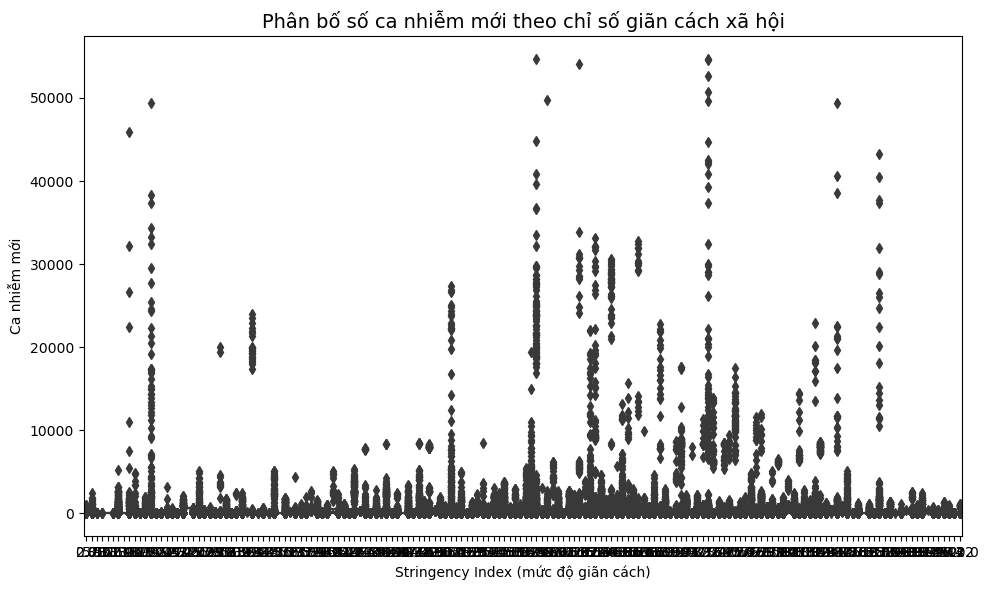

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_forecast,
    x='stringency_index',
    y='new_confirmed',
    palette='coolwarm'
)
plt.title("Phân bố số ca nhiễm mới theo chỉ số giãn cách xã hội", fontsize=14)
plt.xlabel("Stringency Index (mức độ giãn cách)")
plt.ylabel("Ca nhiễm mới")
plt.tight_layout()
plt.show()


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dữ liệu
df = pd.read_csv("df_forecast.csv")

# Chỉ giữ các cột cần thiết
keep_columns = [
    'country_name','date',
    'new_confirmed','new_deceased',
    'cumulative_confirmed','cumulative_deceased',
    'new_vaccine_doses_administered','cumulative_vaccine_doses_administered',
    'population','population_density',
    'stringency_index','school_closing','workplace_closing',
    'stay_at_home_requirements','restrictions_on_internal_movement',
    'gdp_per_capita_usd','human_development_index',
    'average_temperature_celsius','relative_humidity'
]
df = df[keep_columns]

# Điền giá trị thiếu
df_plot = df[['gdp_per_capita_usd', 'human_development_index', 'new_confirmed', 'new_deceased']].fillna(0)

# Scatter plot
plt.figure(figsize=(10,6))
scatter = plt.scatter(
    df_plot['gdp_per_capita_usd'],       # trục X: GDP
    df_plot['new_confirmed'],            # trục Y: ca nhiễm mới
    c=df_plot['human_development_index'], # màu: HDI
    s=df_plot['new_deceased']/10 + 10,  # kích thước: ca tử vong mới
    cmap='viridis',
    alpha=0.7
)

plt.xlabel('GDP per Capita (USD)')
plt.ylabel('New Confirmed Cases')
plt.title('Mối quan hệ Kinh tế – Xã hội và Tác động dịch bệnh')
plt.colorbar(scatter, label='HDI')
plt.grid(True)
plt.show()


KeyError: "['new_deceased', 'cumulative_confirmed', 'cumulative_deceased', 'new_vaccine_doses_administered', 'population', 'population_density', 'school_closing', 'workplace_closing', 'stay_at_home_requirements', 'restrictions_on_internal_movement', 'gdp_per_capita_usd', 'human_development_index'] not in index"

# XÂY DỰNG VÀ HUẤN LUYỆN MÔ HÌNH  DỰ BÁO SỐ CA NHIỄM CHO VIỆT NAM SAU KHI TRỰC QUAN HÓA XONG 

In [66]:
country = "Vietnam"
data = df_forecast[df_forecast["country_name"] == country].copy()

# Chỉ giữ cột ngày và số ca nhiễm mới
data = data[["date", "new_confirmed"]].dropna()

# Đặt index theo thời gian
data = data.sort_values("date")
data.set_index("date", inplace=True)

data.tail()


,new_confirmed
date,
2021-06-28,371.0
2021-06-29,545.0
2021-06-30,675.0
2021-07-01,633.0
2021-07-02,950.0


In [67]:
print(data.index.min(), data.index.max())
print(data.tail())


2020-01-01 00:00:00 2021-07-02 00:00:00
            new_confirmed
date                     
2021-06-28          371.0
2021-06-29          545.0
2021-06-30          675.0
2021-07-01          633.0
2021-07-02          950.0


In [68]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

country = "Vietnam"

# Lọc dữ liệu quốc gia
df_vn = df_forecast[df_forecast["country_name"] == country].copy()
df_vn = df_vn.sort_values("date").reset_index(drop=True)

# Chỉ lấy các biến cần thiết
features = ["new_confirmed", "stringency_index", 
            "cumulative_vaccine_doses_administered",
            "average_temperature_celsius", "relative_humidity"]

df_vn = df_vn[["date"] + features].dropna().reset_index(drop=True)

# Transform log1p để giảm độ bùng phát
df_vn["new_confirmed_log"] = np.log1p(df_vn["new_confirmed"])

# Tạo độ trễ (lag)
for lag in range(1, 15):  # thử 14 ngày trước
    df_vn[f"lag_{lag}"] = df_vn["new_confirmed_log"].shift(lag)

df_vn = df_vn.dropna().reset_index(drop=True)

# Chia train/test theo thời gian
split = int(len(df_vn) * 0.8)
train, test = df_vn.iloc[:split], df_vn.iloc[split:]

# Chuẩn hóa các features
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train[features + [f"lag_{i}" for i in range(1,15)]])
test_scaled = scaler.transform(test[features + [f"lag_{i}" for i in range(1,15)]])

# Target
y_train = train["new_confirmed_log"].values
y_test = test["new_confirmed_log"].values


In [69]:
def create_sequences(data, targets, window=14):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(targets[i])
    return np.array(X), np.array(y)

window = 14
X_train, y_train_seq = create_sequences(train_scaled, y_train, window)
X_test, y_test_seq = create_sequences(test_scaled, y_test, window)

X_train.shape, X_test.shape


((414, 14, 19), (93, 14, 19))